# 03 — Hypothesis Testing, Confidence Intervals & Bias-Variance

**Book references:** *Practical Statistics for Data Scientists* (Bruce & Bruce) — Ch. 2 "Data and Sampling Distributions" (The Bootstrap, Confidence Intervals), Ch. 3 "Statistical Experiments and Significance Testing" (Hypothesis Tests, Statistical Significance and P-Values), Ch. 6 "Statistical Machine Learning" (Bias-Variance Tradeoff, in the K-Nearest Neighbors section)

Part of the Statistics subchapter of the 6-month ML Engineer prep plan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## What a p-value actually means

A **p-value** is the probability, *assuming the null hypothesis is true*, of observing a test statistic at least as extreme as the one actually observed. That's it. It is emphatically **not** "the probability the null hypothesis is true" — that's the single most common misinterpretation, and it's worth internalizing why: the p-value is computed *under the assumption* the null is true, so by construction it can't also tell you how likely that assumption is.

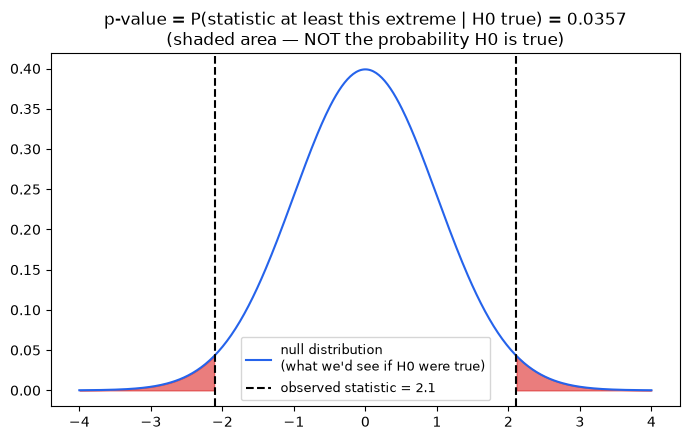

p-value = 0.0357


In [2]:
def visualize_pvalue(savepath: Path = None):
    observed_stat = 2.1   # e.g. a z-score computed from the observed data
    x = np.linspace(-4, 4, 400)
    null_pdf = stats.norm.pdf(x)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(x, null_pdf, color="#2563eb", label="null distribution\n(what we'd see if H0 were true)")
    mask_right = x >= observed_stat
    mask_left = x <= -observed_stat
    ax.fill_between(x[mask_right], null_pdf[mask_right], color="#dc2626", alpha=0.6)
    ax.fill_between(x[mask_left], null_pdf[mask_left], color="#dc2626", alpha=0.6)
    ax.axvline(observed_stat, color="black", linestyle="--", label=f"observed statistic = {observed_stat}")
    ax.axvline(-observed_stat, color="black", linestyle="--")

    p_value = 2 * (1 - stats.norm.cdf(observed_stat))
    ax.set_title(f"p-value = P(statistic at least this extreme | H0 true) = {p_value:.4f}\n"
                 "(shaded area — NOT the probability H0 is true)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return p_value

p_value = visualize_pvalue(FIG_DIR / "pvalue.png")
print(f"p-value = {p_value:.4f}")

The shaded red area (both tails, for a two-sided test) *is* the p-value — literally the probability mass at least as far from the center as what we observed, computed entirely under the null distribution. A small p-value means "this would be a surprising thing to see if there were really no effect," which is evidence *against* the null — but it's not a direct statement about how likely the null is to be true, and it says nothing about the size or practical importance of the effect (statistical significance ≠ practical significance, especially with large samples where even tiny, meaningless effects become "significant").

## Confidence intervals via the bootstrap

A common misreading of a 95% confidence interval is "there's a 95% probability the true value is in this specific interval." The more careful statement: **if you repeated this sampling-and-interval-construction procedure many times, about 95% of the resulting intervals would contain the true value.** The interval itself either does or doesn't contain the truth — the 95% describes the reliability of the *procedure*, not a probability about this one interval.

The **bootstrap** builds such an interval without assuming any particular distribution: resample the data with replacement many times, compute the statistic on each resample, and take percentiles of that empirical distribution.

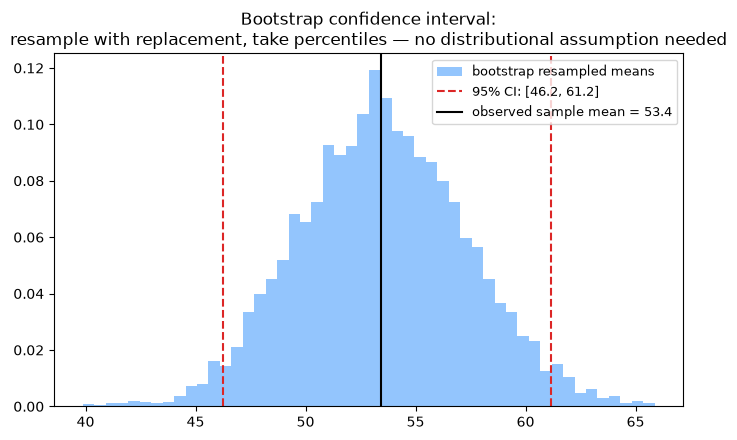

95% bootstrap CI: [46.24, 61.17]


In [3]:
def visualize_bootstrap_ci(savepath: Path = None, rng=None):
    rng = rng or np.random.default_rng(11)
    data = rng.gamma(shape=2, scale=25, size=80)   # skewed data on purpose -- no normality assumption needed

    n_boot = 5000
    boot_means = np.array([rng.choice(data, size=len(data), replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    observed_mean = data.mean()

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(boot_means, bins=50, color="#93c5fd", density=True, label="bootstrap resampled means")
    ax.axvline(lo, color="#dc2626", linestyle="--", label=f"95% CI: [{lo:.1f}, {hi:.1f}]")
    ax.axvline(hi, color="#dc2626", linestyle="--")
    ax.axvline(observed_mean, color="black", label=f"observed sample mean = {observed_mean:.1f}")
    ax.legend(fontsize=9)
    ax.set_title("Bootstrap confidence interval:\nresample with replacement, take percentiles — no distributional assumption needed")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return lo, hi

lo, hi = visualize_bootstrap_ci(FIG_DIR / "bootstrap_ci.png")
print(f"95% bootstrap CI: [{lo:.2f}, {hi:.2f}]")

Note the data itself was drawn from a skewed Gamma distribution, not a Gaussian — the bootstrap doesn't care. That's its main practical advantage over classical formula-based confidence intervals, which often assume normality: it works directly off the empirical resampling distribution, whatever shape the underlying data has.

## The bias-variance tradeoff

Expected prediction error decomposes into three pieces:

```
Expected Error = Bias² + Variance + Irreducible Noise
```

- **Bias** — error from an overly simplistic model that can't capture the true pattern (underfitting).
- **Variance** — error from a model that's too sensitive to the specific training sample, capturing noise instead of signal (overfitting).
- **Irreducible noise** — error that no model can remove; inherent randomness in the data-generating process.

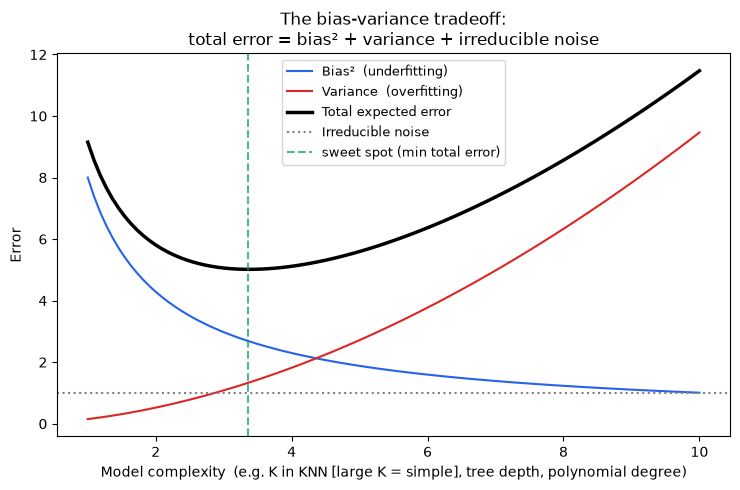

In [4]:
def visualize_bias_variance_curve(savepath: Path = None):
    complexity = np.linspace(1, 10, 100)
    bias_sq = 8 / complexity**0.9
    variance = 0.15 * complexity**1.8
    irreducible = 1.0
    total_error = bias_sq + variance + irreducible

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.plot(complexity, bias_sq, color="#2563eb", label="Bias²  (underfitting)")
    ax.plot(complexity, variance, color="#dc2626", label="Variance  (overfitting)")
    ax.plot(complexity, total_error, color="black", linewidth=2.5, label="Total expected error")
    ax.axhline(irreducible, color="gray", linestyle=":", label="Irreducible noise")

    best_idx = np.argmin(total_error)
    ax.axvline(complexity[best_idx], color="#059669", linestyle="--", alpha=0.7, label="sweet spot (min total error)")

    ax.set_xlabel("Model complexity  (e.g. K in KNN [large K = simple], tree depth, polynomial degree)")
    ax.set_ylabel("Error")
    ax.legend(fontsize=9)
    ax.set_title("The bias-variance tradeoff:\ntotal error = bias² + variance + irreducible noise")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_bias_variance_curve(FIG_DIR / "bias_variance_curve.png")

Two intuitive examples worth having ready:
- **K in KNN:** small K (e.g., K=1) means low bias but high variance — the prediction chases every quirk of the nearest single point. Large K oversmooths — high bias, low variance.
- **Tree depth:** a shallow tree underfits (high bias); an unconstrained deep tree memorizes training data (high variance) — which is exactly why techniques like pruning, minimum leaf size, and ensembling (random forests average away variance across many high-variance trees) exist.

This is also the same curve underlying the classic **train/validation error vs. model complexity** diagnostic plot: training error keeps falling as complexity increases (the model can always fit the training data better), while validation error is U-shaped — falling as bias drops, then rising again as variance takes over. Reading that gap between train and validation error is the standard practical diagnostic for "is my model underfitting or overfitting."

---

## Self-check before moving on

- [ ] I can state precisely what a p-value means, and identify the most common misinterpretation
- [ ] I can explain what "95% confidence" actually refers to (reliability of the procedure, not probability of this one interval)
- [ ] I can explain how the bootstrap constructs a confidence interval without a normality assumption
- [ ] I can state the bias-variance decomposition of expected error and give two concrete examples
- [ ] I can connect the bias-variance curve to the practical train/validation error diagnostic

This closes out the Statistics subchapter — and the full Math Foundations chapter (Linear Algebra → Calculus → Statistics). Next up in the 6-month plan: **Month 2, Classical ML** (feature engineering, tree ensembles, SVMs, clustering).